# Error Relationship Analysis: Can We Predict Forecast Uncertainty?

---

## Purpose
This notebook investigates whether **prediction errors** from our optimal forecast models show systematic relationships with ECMWF input variables. *Can we build a separate model to predict forecast uncertainty?*

## Two-Stage Modeling Framework
#### **Mean Prediction**
#### **Uncertainty Prediction**

## Key Questions

1. **Is there signal?** Do errors correlate with ECMWF inputs?
2. **Heteroscedasticity:** Does error variance change with input values?
3. **Which inputs matter?** Ensemble mean vs. variance for predicting uncertainty?
4. **Seasonality:** Do error patterns differ by season?
5. **Model feasibility:** Is there enough signal to justify an uncertainty model?

# Setup & Configuration

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneOut
from scipy import stats

# Load Data

In [ ]:
# Load merged data with seasons from Final Data directory
data_file = Path('000000 Final Data/eastnor/3_eobs_ecmwf_merged_with_seasons.csv')

df = pd.read_csv(data_file)

# Load Model Predictions from Saved Results

We load the LOOCV predictions from the optimal models identified in Notebook 5.

## WDF Model Predictions (Pooled)

In [ ]:
wdf_pred_file = Path('000000 Final Data/eastnor/model_results/predictions') / \
                'run_20251229_014846--LinearRegression--ecmwf_mean_var--wdf--all.csv'

if not wdf_pred_file.exists():
    # Try to find the file
    pred_dir = Path('000000 Final Data/eastnor/model_results/predictions')
    matching_files = list(pred_dir.glob('*LinearRegression--ecmwf_mean_var--wdf--all.csv'))
    if matching_files:
        wdf_pred_file = matching_files[0]

# Load predictions
wdf_results = pd.read_csv(wdf_pred_file)
wdf_results['time'] = pd.to_datetime(wdf_results['time'])

# Calculate errors
wdf_results['error'] = wdf_results['y_pred'] - wdf_results['y_true']
wdf_results['abs_error'] = wdf_results['error'].abs()
wdf_results['squared_error'] = wdf_results['error'] ** 2

wdf_results.head(3)

LOADING WDF PREDICTIONS

✅ WDF predictions loaded
   File: run_20251229_014846--LinearRegression--ecmwf_mean_var--wdf--all.csv
   Samples: 368
   RMSE: 0.1153
   MAE: 0.0904
   Mean error: 0.0000
   Std error: 0.1155

Columns: ['time', 'y_pred', 'y_true', 'error', 'abs_error', 'squared_error']


,time,y_pred,y_true,error,abs_error,squared_error
0,1993-03-31,0.304183,0.121976,0.182207,0.182207,0.033199
1,1993-04-30,0.339490,0.151042,0.188448,0.188448,0.035513
2,1993-05-31,0.373775,0.433972,-0.060196,0.060196,0.003624


## SPI-1 Model Predictions (Seasonal)

In [ ]:
pred_dir = Path('000000 Final Data/eastnor/model_results/predictions')
seasons = ['Winter', 'Spring', 'Summer', 'Fall']
season_map = {'Winter': 'winter', 'Spring': 'spring', 'Summer': 'summer', 'Fall': 'fall'}

spi_predictions = []

for season in seasons:
    season_lower = season_map[season]
    
    matching_files = list(pred_dir.glob(f'*LinearRegression--ecmwf_mean--spi-1--{season_lower}.csv'))
    
    if not matching_files:
        matching_files = list(pred_dir.glob(f'*LinearRegression--ecmwf_mean--spi*--{season_lower}.csv'))
    
    if matching_files:
        pred_file = matching_files[0]
        df_season = pd.read_csv(pred_file)
        df_season['time'] = pd.to_datetime(df_season['time'])
        df_season['season'] = season
        spi_predictions.append(df_season)

if len(spi_predictions) == 0:
    raise FileNotFoundError("No SPI-1 seasonal predictions found. Check file naming patterns.")

# Combine all seasons
spi_results = pd.concat(spi_predictions, ignore_index=True)

# Calculate errors
spi_results['error'] = spi_results['y_pred'] - spi_results['y_true']
spi_results['abs_error'] = spi_results['error'].abs()
spi_results['squared_error'] = spi_results['error'] ** 2

spi_results.head(3)

# Brief Comparison: Pooled vs Seasonal Error Patterns

## Load Additional Configurations

In [ ]:
pred_dir = Path('000000 Final Data/eastnor/model_results/predictions')

# WDF Seasonal: LinearRegression + ecmwf_mean (seasonal)
print("\n1. WDF Seasonal (LinearRegression + ecmwf_mean)")
seasons = ['Winter', 'Spring', 'Summer', 'Fall']
season_map = {'Winter': 'winter', 'Spring': 'spring', 'Summer': 'summer', 'Fall': 'fall'}

wdf_seasonal_predictions = []
for season in seasons:
    season_lower = season_map[season]
    matching_files = list(pred_dir.glob(f'*LinearRegression--ecmwf_mean--wdf--{season_lower}.csv'))
    
    if matching_files:
        pred_file = matching_files[0]
        df_season = pd.read_csv(pred_file)
        df_season['time'] = pd.to_datetime(df_season['time'])
        df_season['season'] = season
        wdf_seasonal_predictions.append(df_season)

if wdf_seasonal_predictions:
    wdf_seasonal_results = pd.concat(wdf_seasonal_predictions, ignore_index=True)
    wdf_seasonal_results['error'] = wdf_seasonal_results['y_pred'] - wdf_seasonal_results['y_true']
    wdf_seasonal_results['abs_error'] = wdf_seasonal_results['error'].abs()

if matching_files:
    spi_pooled_results = pd.read_csv(matching_files[0])
    spi_pooled_results['time'] = pd.to_datetime(spi_pooled_results['time'])
    spi_pooled_results['error'] = spi_pooled_results['y_pred'] - spi_pooled_results['y_true']
    spi_pooled_results['abs_error'] = spi_pooled_results['error'].abs()

## Merge All Configurations with ECMWF Inputs

In [ ]:
df['time'] = pd.to_datetime(df['time'])

ecmwf_features = ['ecmwf_press_ensmean', 'ecmwf_temp_ensmean', 'ecmwf_precip_ensmean',
                  'ecmwf_press_ensvar', 'ecmwf_temp_ensvar', 'ecmwf_precip_ensvar']

wdf_pooled_analysis = wdf_results.merge(df[['time'] + ecmwf_features], on='time', how='left')
wdf_pooled_analysis['config'] = 'WDF_Pooled_Optimal'

if wdf_seasonal_results is not None:
    wdf_seasonal_analysis = wdf_seasonal_results.merge(df[['time'] + ecmwf_features], on='time', how='left')
    wdf_seasonal_analysis['config'] = 'WDF_Seasonal'

if spi_pooled_results is not None:
    spi_pooled_analysis = spi_pooled_results.merge(df[['time'] + ecmwf_features], on='time', how='left')
    spi_pooled_analysis['config'] = 'SPI1_Pooled'

spi_seasonal_analysis = spi_results.merge(df[['time'] + ecmwf_features], on='time', how='left')
spi_seasonal_analysis['config'] = 'SPI1_Seasonal_Optimal'


## Correlation Comparison Across Configurations

Compare error-input correlations across pooled vs seasonal training.

In [ ]:
print("\nQuestion: Do error-input relationships differ between pooled and seasonal?\n")

comparison_data = []

for config_name, data in [
    ('WDF Pooled (Optimal)', wdf_pooled_analysis),
    ('WDF Seasonal', wdf_seasonal_analysis),
    ('SPI-1 Pooled', spi_pooled_analysis),
    ('SPI-1 Seasonal (Optimal)', spi_seasonal_analysis)
]:
    if data is not None:
        # Calculate correlations with absolute error (most relevant for uncertainty)
        corr_precip_mean = data[['ecmwf_precip_ensmean', 'abs_error']].corr().iloc[0, 1]
        corr_precip_var = data[['ecmwf_precip_ensvar', 'abs_error']].corr().iloc[0, 1]
        corr_temp_mean = data[['ecmwf_temp_ensmean', 'abs_error']].corr().iloc[0, 1]
        corr_temp_var = data[['ecmwf_temp_ensvar', 'abs_error']].corr().iloc[0, 1]
        
        comparison_data.append({
            'Configuration': config_name,
            'RMSE': np.sqrt((data['error']**2).mean()),
            'Precip_Mean': corr_precip_mean,
            'Precip_Var': corr_precip_var,
            'Temp_Mean': corr_temp_mean,
            'Temp_Var': corr_temp_var,
            'Max_|Corr|': max(abs(corr_precip_mean), abs(corr_precip_var), 
                             abs(corr_temp_mean), abs(corr_temp_var))
        })

comparison_df = pd.DataFrame(comparison_data)
max_corr_all = comparison_df['Max_|Corr|'].max()

# Check consistency across training strategies
wdf_diff = abs(comparison_df[comparison_df['Configuration'].str.contains('WDF')]['Max_|Corr|'].diff().iloc[-1])
spi_diff = abs(comparison_df[comparison_df['Configuration'].str.contains('SPI')]['Max_|Corr|'].diff().iloc[-1])

CORRELATION COMPARISON: ERROR VS ECMWF INPUTS

Question: Do error-input relationships differ between pooled and seasonal?


Correlations between |Error| and ECMWF Inputs:
           Configuration     RMSE  Precip_Mean  Precip_Var  Temp_Mean  Temp_Var  Max_|Corr|
    WDF Pooled (Optimal) 0.115347     0.065209    0.001595   0.046435 -0.009257    0.065209
            WDF Seasonal 0.116798     0.078140    0.017499   0.056334 -0.030191    0.078140
            SPI-1 Pooled 0.946610    -0.055230   -0.007357  -0.001031 -0.003556    0.055230
SPI-1 Seasonal (Optimal) 0.945741    -0.044737   -0.003056   0.003780 -0.007063    0.044737

INTERPRETATION

✅ FINDING: Weak correlations (|r| < 0.2) across ALL configurations
   → Error-input relationships are consistently weak
   → Training strategy (pooled vs seasonal) doesn't create strong patterns

Consistency check:
  WDF: Max|Corr| difference between pooled/seasonal = 0.013
  SPI-1: Max|Corr| difference between pooled/seasonal = 0.010

✅ Error patter

---

# Deep Analysis: Optimal Models Only

Based on the comparison above, we now proceed with detailed analysis of the **2 optimal models**:
- **WDF:** Pooled (skill: 0.161)
- **SPI-1:** Seasonal (skill: 0.050)

These are the models we're deploying to Fennoscandia.

---

## Prepare Data for Deep Analysis

In [51]:
# Use the optimal configurations for deep analysis
wdf_analysis = wdf_pooled_analysis.copy()
spi_analysis = spi_seasonal_analysis.copy()

print("="*70)
print("DATA PREPARED FOR DEEP ANALYSIS")
print("="*70)
print(f"\nWDF (Pooled Optimal): {wdf_analysis.shape}")
print(f"SPI-1 (Seasonal Optimal): {spi_analysis.shape}")
print("\nProceeding with error distribution, correlation, and heteroscedasticity analyses...")

DATA PREPARED FOR DEEP ANALYSIS

WDF (Pooled Optimal): (368, 13)
SPI-1 (Seasonal Optimal): (368, 14)

Proceeding with error distribution, correlation, and heteroscedasticity analyses...


In [ ]:
df['time'] = pd.to_datetime(df['time'])

# Define feature columns, now including eobs-1 and eobs-2 variants for press, temp, and precip
X_features_wdf = [
    'ecmwf_press_ensmean', 'ecmwf_temp_ensmean', 'ecmwf_precip_ensmean',
    'ecmwf_press_ensvar',  'ecmwf_temp_ensvar',  'ecmwf_precip_ensvar',
    'eobs_press_-1', 'eobs_press_-2',
    'eobs_temp_-1',  'eobs_temp_-2',
    'eobs_precip_-1','eobs_precip_-2'
]
X_features_spi = [
    'ecmwf_press_ensmean', 'ecmwf_temp_ensmean', 'ecmwf_precip_ensmean',
    'ecmwf_press_ensvar',  'ecmwf_temp_ensvar',  'ecmwf_precip_ensvar',
    'eobs_press_-1', 'eobs_press_-2',
    'eobs_temp_-1',  'eobs_temp_-2',
    'eobs_precip_-1','eobs_precip_-2'
]
wdf_analysis = wdf_results.merge(df[['time'] + X_features_wdf + ['season']], on='time', how='left')
spi_analysis = spi_results.merge(df[['time'] + X_features_spi], on='time', how='left')

# Verify merge was successful
if wdf_analysis[X_features_wdf].isnull().any().any():
    for col in X_features_wdf:
        missing = wdf_analysis[col].isnull().sum()

if spi_analysis[X_features_spi].isnull().any().any():
    for col in X_features_spi:
        missing = spi_analysis[col].isnull().sum()

# Error Distribution Analysis

First, let's examine the distribution of prediction errors.

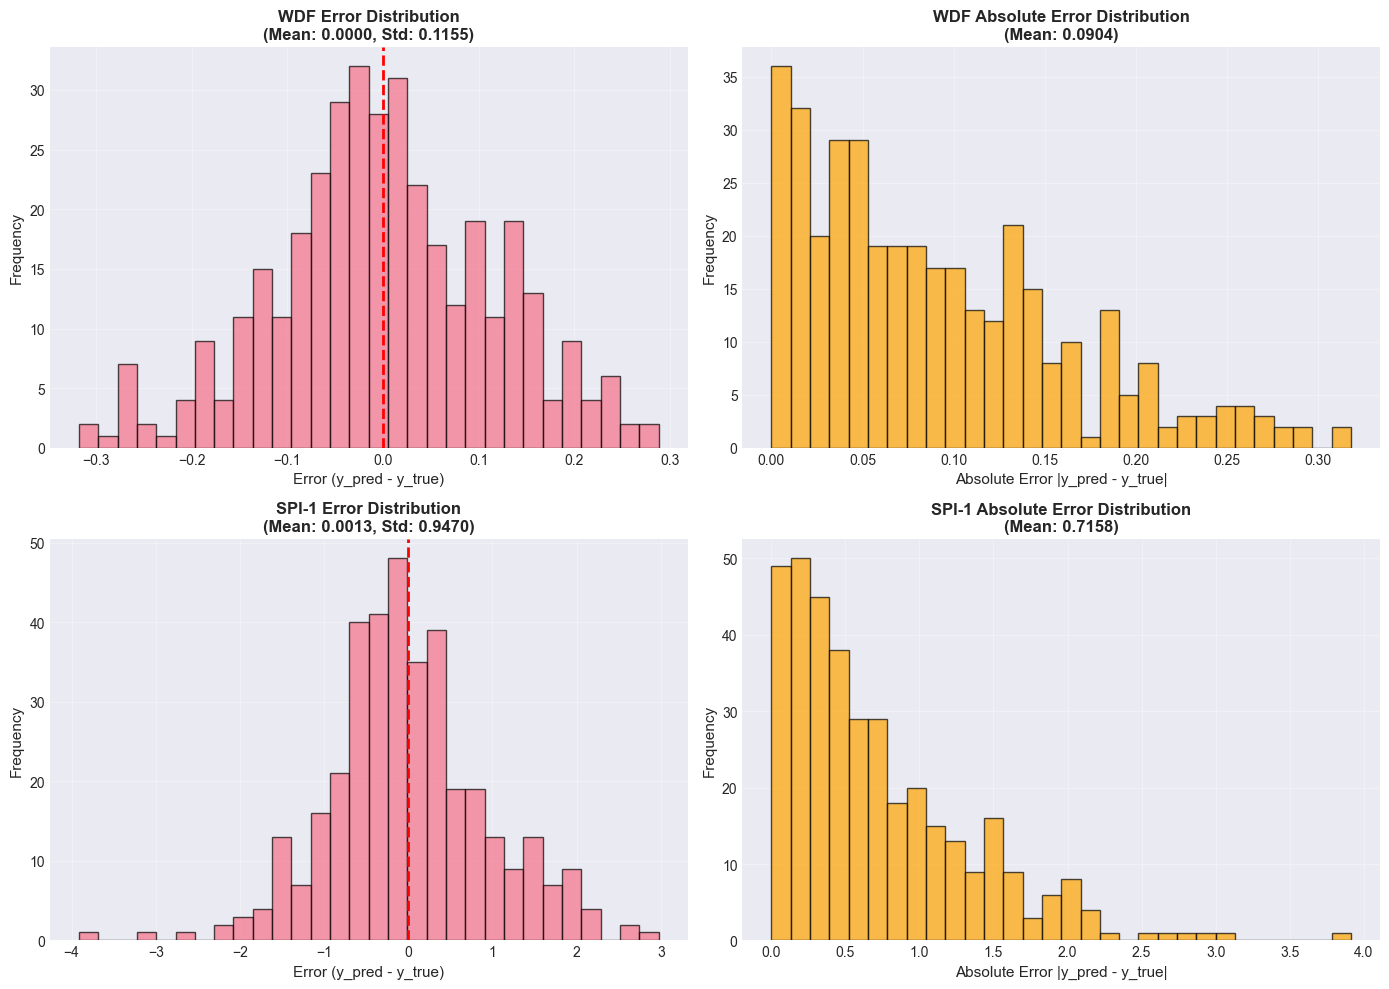

✅ Error distribution plot saved: error_distributions.png


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(wdf_analysis['error'], bins=30, alpha=0.7, edgecolor='black')
axes[0, 0].axvline(0, color='red', linestyle='--', linewidth=2)
axes[0, 0].set_xlabel('Error (y_pred - y_true)', fontsize=11)
axes[0, 0].set_ylabel('Frequency', fontsize=11)
axes[0, 0].set_title(f'WDF Error Distribution\n(Mean: {wdf_analysis["error"].mean():.4f}, Std: {wdf_analysis["error"].std():.4f})', 
                     fontsize=12, fontweight='bold')
axes[0, 0].grid(alpha=0.3)

axes[0, 1].hist(wdf_analysis['abs_error'], bins=30, alpha=0.7, edgecolor='black', color='orange')
axes[0, 1].set_xlabel('Absolute Error |y_pred - y_true|', fontsize=11)
axes[0, 1].set_ylabel('Frequency', fontsize=11)
axes[0, 1].set_title(f'WDF Absolute Error Distribution\n(Mean: {wdf_analysis["abs_error"].mean():.4f})', 
                     fontsize=12, fontweight='bold')
axes[0, 1].grid(alpha=0.3)

axes[1, 0].hist(spi_analysis['error'], bins=30, alpha=0.7, edgecolor='black')
axes[1, 0].axvline(0, color='red', linestyle='--', linewidth=2)
axes[1, 0].set_xlabel('Error (y_pred - y_true)', fontsize=11)
axes[1, 0].set_ylabel('Frequency', fontsize=11)
axes[1, 0].set_title(f'SPI-1 Error Distribution\n(Mean: {spi_analysis["error"].mean():.4f}, Std: {spi_analysis["error"].std():.4f})', 
                     fontsize=12, fontweight='bold')
axes[1, 0].grid(alpha=0.3)

axes[1, 1].hist(spi_analysis['abs_error'], bins=30, alpha=0.7, edgecolor='black', color='orange')
axes[1, 1].set_xlabel('Absolute Error |y_pred - y_true|', fontsize=11)
axes[1, 1].set_ylabel('Frequency', fontsize=11)
axes[1, 1].set_title(f'SPI-1 Absolute Error Distribution\n(Mean: {spi_analysis["abs_error"].mean():.4f})', 
                     fontsize=12, fontweight='bold')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('error_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

## Scatter Plots - Error vs ECMWF Inputs

### WDF Analysis

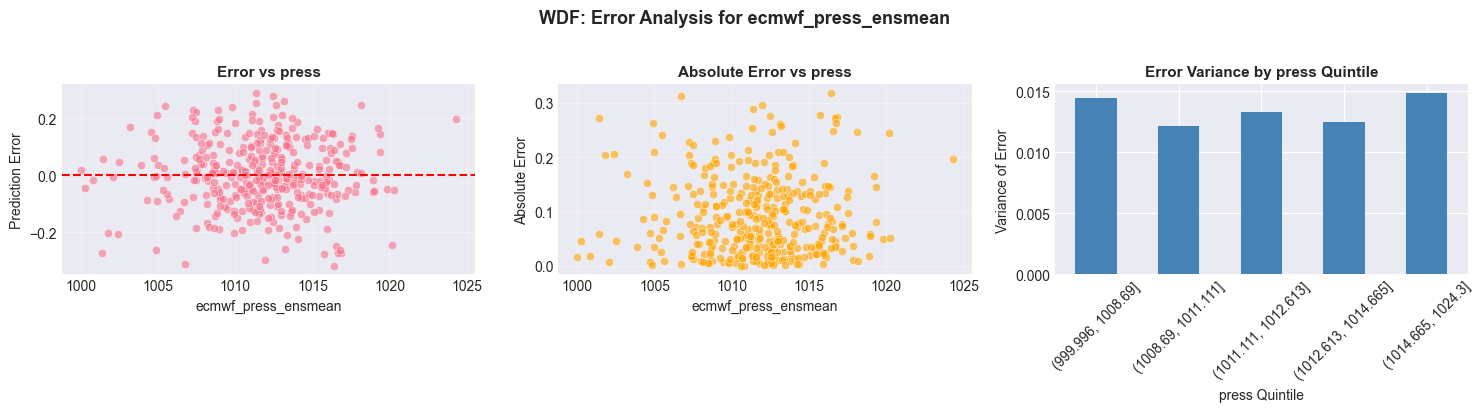

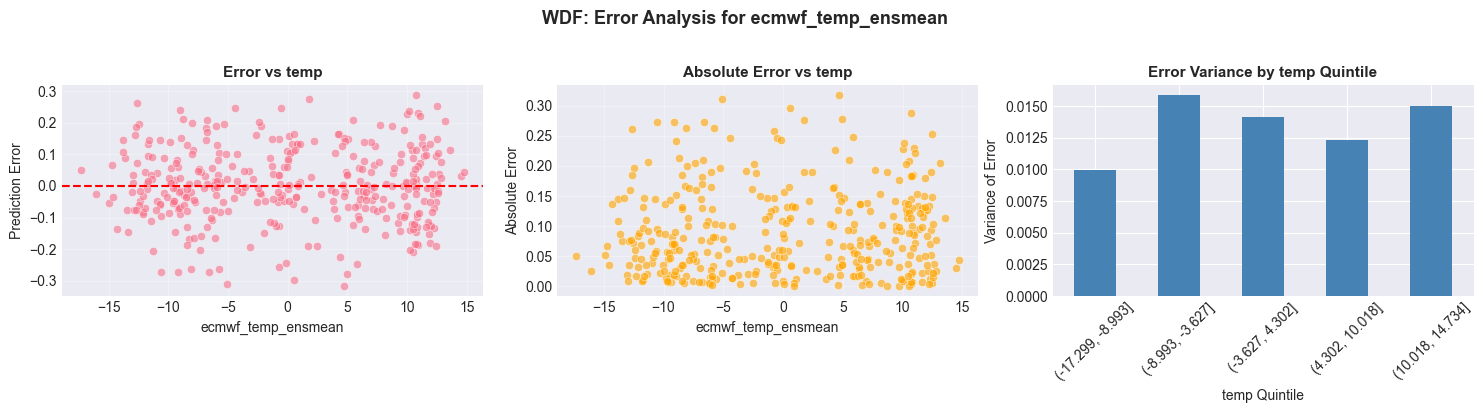

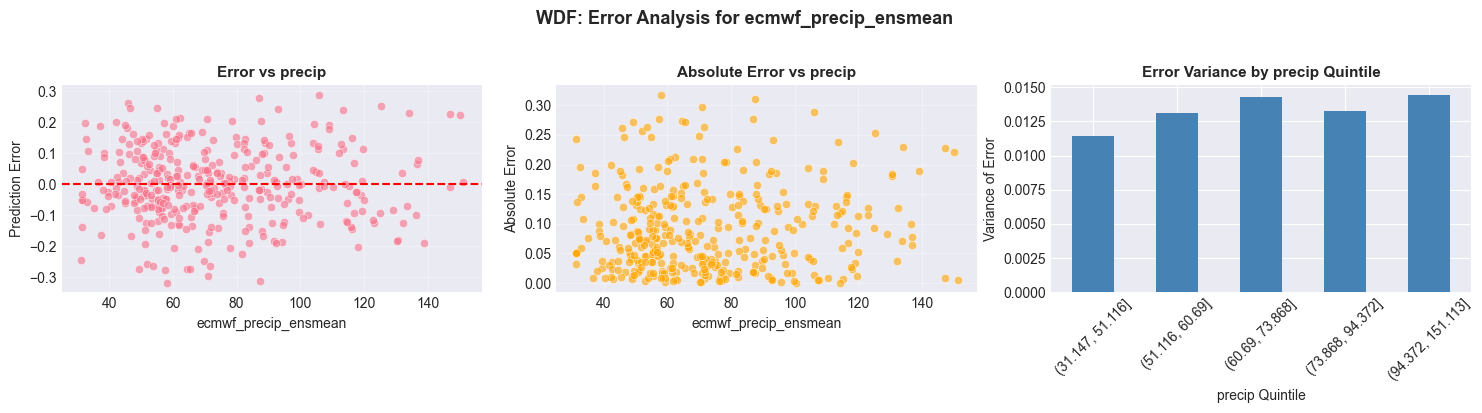

✅ WDF scatter plots complete


In [ ]:
# WDF: Detailed scatter analysis
for var in ['ecmwf_press_ensmean', 'ecmwf_temp_ensmean', 'ecmwf_precip_ensmean']:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    # Error vs variable
    sns.scatterplot(x=wdf_analysis[var], y=wdf_analysis['error'], alpha=0.6, ax=axes[0])
    axes[0].axhline(0, color='red', linestyle='--', linewidth=1.5)
    axes[0].set_xlabel(var, fontsize=10)
    axes[0].set_ylabel('Prediction Error', fontsize=10)
    axes[0].set_title(f'Error vs {var.split("_")[1]}', fontsize=11, fontweight='bold')
    axes[0].grid(alpha=0.3)
    
    # Absolute error vs variable
    sns.scatterplot(x=wdf_analysis[var], y=wdf_analysis['abs_error'], alpha=0.6, 
                    color='orange', ax=axes[1])
    axes[1].set_xlabel(var, fontsize=10)
    axes[1].set_ylabel('Absolute Error', fontsize=10)
    axes[1].set_title(f'Absolute Error vs {var.split("_")[1]}', fontsize=11, fontweight='bold')
    axes[1].grid(alpha=0.3)
    
    # Binned variance
    wdf_analysis['bin_temp'] = pd.qcut(wdf_analysis[var], q=5, duplicates='drop')
    bin_var = wdf_analysis.groupby('bin_temp')['error'].var()
    bin_var.plot(kind='bar', ax=axes[2], color='steelblue')
    axes[2].set_title(f'Error Variance by {var.split("_")[1]} Quintile', fontsize=11, fontweight='bold')
    axes[2].set_ylabel('Variance of Error', fontsize=10)
    axes[2].set_xlabel(f'{var.split("_")[1]} Quintile', fontsize=10)
    axes[2].tick_params(axis='x', rotation=45)
    
    plt.suptitle(f'WDF: Error Analysis for {var}', fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

### SPI-1 Analysis

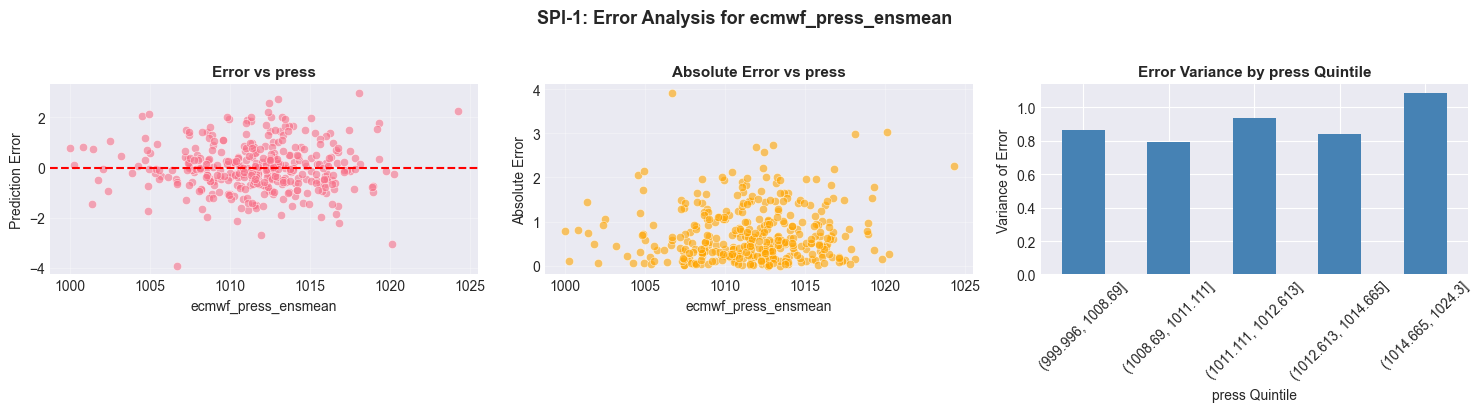

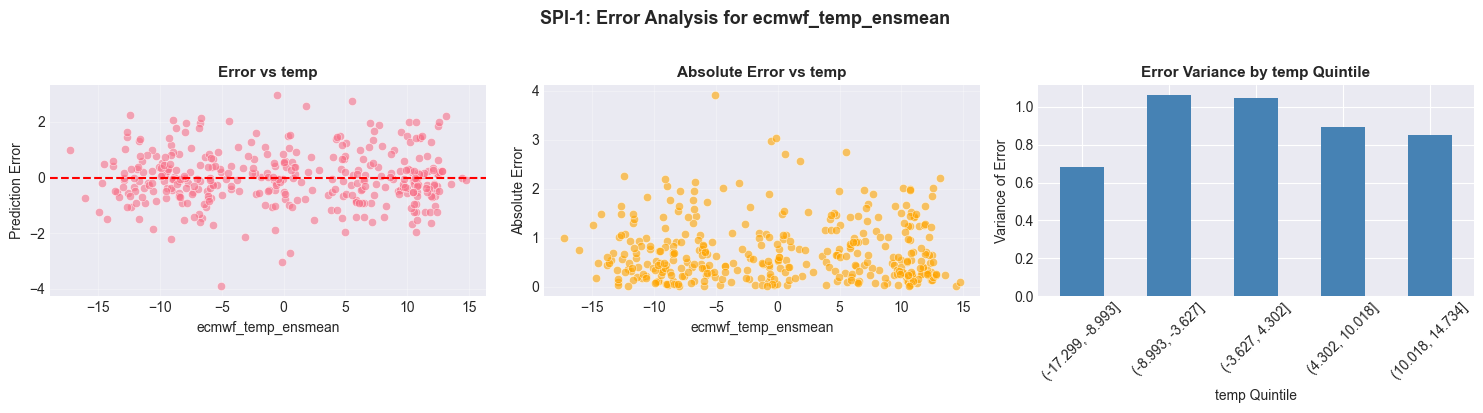

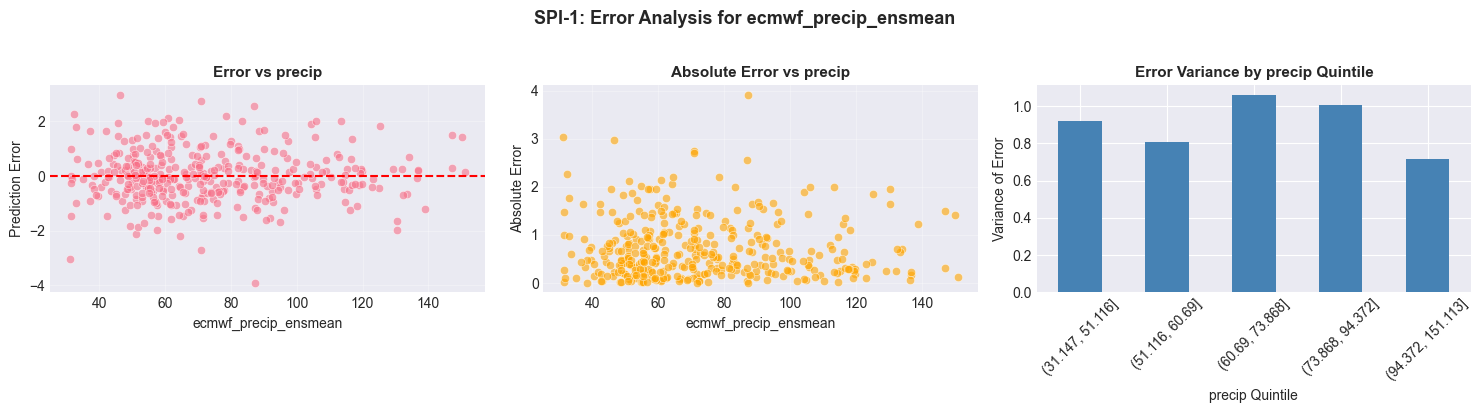

✅ SPI-1 scatter plots complete


In [ ]:
for var in ['ecmwf_press_ensmean', 'ecmwf_temp_ensmean', 'ecmwf_precip_ensmean']:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    # Error vs variable
    sns.scatterplot(x=spi_analysis[var], y=spi_analysis['error'], alpha=0.6, ax=axes[0])
    axes[0].axhline(0, color='red', linestyle='--', linewidth=1.5)
    axes[0].set_xlabel(var, fontsize=10)
    axes[0].set_ylabel('Prediction Error', fontsize=10)
    axes[0].set_title(f'Error vs {var.split("_")[1]}', fontsize=11, fontweight='bold')
    axes[0].grid(alpha=0.3)
    
    # Absolute error vs variable
    sns.scatterplot(x=spi_analysis[var], y=spi_analysis['abs_error'], alpha=0.6, 
                    color='orange', ax=axes[1])
    axes[1].set_xlabel(var, fontsize=10)
    axes[1].set_ylabel('Absolute Error', fontsize=10)
    axes[1].set_title(f'Absolute Error vs {var.split("_")[1]}', fontsize=11, fontweight='bold')
    axes[1].grid(alpha=0.3)
    
    # Binned variance
    spi_analysis['bin_temp'] = pd.qcut(spi_analysis[var], q=5, duplicates='drop')
    bin_var = spi_analysis.groupby('bin_temp')['error'].var()
    bin_var.plot(kind='bar', ax=axes[2], color='steelblue')
    axes[2].set_title(f'Error Variance by {var.split("_")[1]} Quintile', fontsize=11, fontweight='bold')
    axes[2].set_ylabel('Variance of Error', fontsize=10)
    axes[2].set_xlabel(f'{var.split("_")[1]} Quintile', fontsize=10)
    axes[2].tick_params(axis='x', rotation=45)
    
    plt.suptitle(f'SPI-1: Error Analysis for {var}', fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()